# Capstone Session 8

This notebook is generated from the copied `Capstone_Session_8.pdf` directions and the staged `movies.csv` and `ratings.csv` datasets.

## Objective

Demonstrate user-based, item-based, and model-based recommendation techniques using the staged movie ratings data.

## Environment Note

The PDF names `KNNBasic`, `SVD`, and `NMF`, which are commonly run through `scikit-surprise`. That package cannot be built in this Python 3.12 Windows environment without Microsoft C++ Build Tools, so the notebook records a compatible fallback: a manual KNN/MSD recommender plus `TruncatedSVD` and `NMF` cross-validation over the same staged ratings matrix.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.decomposition import NMF, TruncatedSVD
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import KFold

BASE_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Machine Learning Using Python/Capstone Session 8''')
MOVIES_PATH = BASE_DIR / 'movies.csv'
RATINGS_PATH = BASE_DIR / 'ratings.csv'
OUTPUTS_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Machine Learning Using Python/Capstone Session 8/outputs''')
PLOTS_DIR = Path(r'''X:/SIMPLILEARN/FrancisBurnetCom/Incremental Capstones/Machine Learning Using Python/Capstone Session 8/outputs/plots''')
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

In [2]:
movies = pd.read_csv(MOVIES_PATH)
ratings = pd.read_csv(RATINGS_PATH)
merged = ratings.merge(movies[['movieId', 'title']], on='movieId', how='left')
user_item = merged.pivot_table(index='userId', columns='title', values='rating')
display(merged.head())
print('Movies shape:', movies.shape)
print('Ratings shape:', ratings.shape)
print('User-item shape:', user_item.shape)

,userId,movieId,rating,timestamp,title
0,1,1,4.0,964982703,Toy Story (1995)
1,1,3,4.0,964981247,Grumpier Old Men (1995)
2,1,6,4.0,964982224,Heat (1995)
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995)
4,1,50,5.0,964982931,"Usual Suspects, The (1995)"


Movies shape: (9742, 3)
Ratings shape: (100836, 4)
User-item shape: (610, 9719)


In [3]:
user_filled = user_item.apply(lambda row: row.fillna(row.mean()), axis=1)
user_corr = user_filled.T.corr()
user_1_corr = user_corr.loc[1].drop(index=1).dropna().sort_values(ascending=False)
top_50_users = user_1_corr.head(50)
movie_32_title = movies.loc[movies['movieId'] == 32, 'title'].iloc[0]
movie_32_ratings = merged.loc[merged['movieId'] == 32, ['userId', 'rating']].set_index('userId')
eligible = top_50_users[top_50_users.index.isin(movie_32_ratings.index)]
if eligible.empty:
    predicted_user_1_rating = float(merged.loc[merged['movieId'] == 32, 'rating'].mean())
else:
    weighted_ratings = movie_32_ratings.loc[eligible.index, 'rating']
    denominator = float(np.abs(eligible).sum())
    predicted_user_1_rating = float(np.dot(eligible.values, weighted_ratings.values) / denominator) if denominator else float(weighted_ratings.mean())

top_50_df = top_50_users.reset_index()
top_50_df.columns = ['userId', 'correlation']
top_50_df.to_csv(OUTPUTS_DIR / 'session_8_top_50_user_correlations.csv', index=False)
display(top_50_df.head(10))
{'movieId_32_title': movie_32_title, 'predicted_user_1_rating_for_movie_32': round(predicted_user_1_rating, 4)}

,userId,correlation
0,301,0.124799
1,597,0.102631
2,414,0.101348
3,477,0.099217
4,57,0.099070
5,369,0.098295
6,206,0.096852
7,535,0.096493
8,590,0.095191
9,418,0.094153


{'movieId_32_title': 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)',
 'predicted_user_1_rating_for_movie_32': 4.1369}

In [4]:
item_filled = user_item.apply(lambda column: column.fillna(column.mean()), axis=0)
movie_corr = item_filled.corr()
jurassic_title = 'Jurassic Park (1993)'
jurassic_similar = movie_corr[jurassic_title].drop(index=jurassic_title).dropna().sort_values(ascending=False).head(10)
similar_movies_df = jurassic_similar.reset_index()
similar_movies_df.columns = ['title', 'correlation']
similar_movies_df.to_csv(OUTPUTS_DIR / 'session_8_similar_movies.csv', index=False)
display(similar_movies_df)

,title,correlation
0,"Fugitive, The (1993)",0.324717
1,Lethal Weapon (1987),0.318646
2,Independence Day (a.k.a. ID4) (1996),0.263629
3,Mission: Impossible (1996),0.258080
4,Ghostbusters (a.k.a. Ghost Busters) (1984),0.256527
5,Mulan (1998),0.255672
6,Rise of the Planet of the Apes (2011),0.248134
7,"Bug's Life, A (1998)",0.240964
8,Indiana Jones and the Temple of Doom (1984),0.239826
9,Die Hard (1988),0.239294


In [5]:
all_user_ids = sorted(ratings['userId'].unique())
all_movie_ids = sorted(ratings['movieId'].unique())
user_index = {user_id: idx for idx, user_id in enumerate(all_user_ids)}
movie_index = {movie_id: idx for idx, movie_id in enumerate(all_movie_ids)}
global_mean = float(ratings['rating'].mean())

def build_train_matrix(train_df):
    return train_df.pivot(index='userId', columns='movieId', values='rating').reindex(index=all_user_ids, columns=all_movie_ids)

def predict_knn_msd(train_df, test_df, neighbors=20):
    train_matrix = build_train_matrix(train_df)
    user_means = train_matrix.mean(axis=1).fillna(global_mean)
    filled = train_matrix.apply(lambda row: row.fillna(user_means.loc[row.name]), axis=1)
    msd = pairwise_distances(filled, metric='sqeuclidean') / filled.shape[1]
    similarity = 1 / (1 + msd)
    predictions = []
    for row in test_df.itertuples(index=False):
        user_id = int(row.userId)
        movie_id = int(row.movieId)
        uidx = user_index[user_id]
        midx = movie_index[movie_id]
        movie_ratings = train_matrix.iloc[:, midx]
        rated_mask = movie_ratings.notna().to_numpy(copy=True)
        rated_mask[uidx] = False
        if not rated_mask.any():
            predictions.append(global_mean)
            continue
        neighbor_scores = similarity[uidx, rated_mask]
        neighbor_ratings = movie_ratings[rated_mask].to_numpy(dtype=float)
        if neighbor_scores.size > neighbors:
            top_idx = np.argsort(neighbor_scores)[-neighbors:]
            neighbor_scores = neighbor_scores[top_idx]
            neighbor_ratings = neighbor_ratings[top_idx]
        denominator = float(np.abs(neighbor_scores).sum())
        if denominator == 0:
            predictions.append(float(np.nanmean(neighbor_ratings)))
        else:
            predictions.append(float(np.dot(neighbor_scores, neighbor_ratings) / denominator))
    return np.clip(np.array(predictions), 0.5, 5.0)

def predict_svd(train_df, test_df, n_components=20):
    train_matrix = build_train_matrix(train_df)
    user_means = train_matrix.mean(axis=1).fillna(global_mean)
    filled = train_matrix.apply(lambda row: row.fillna(user_means.loc[row.name]), axis=1)
    model = TruncatedSVD(n_components=n_components, random_state=42)
    latent = model.fit_transform(filled)
    reconstructed = latent @ model.components_
    predictions = []
    for row in test_df.itertuples(index=False):
        predictions.append(float(reconstructed[user_index[int(row.userId)], movie_index[int(row.movieId)]]))
    return np.clip(np.array(predictions), 0.5, 5.0)

def predict_nmf(train_df, test_df, n_components=20):
    train_matrix = build_train_matrix(train_df)
    user_means = train_matrix.mean(axis=1).fillna(global_mean)
    filled = train_matrix.apply(lambda row: row.fillna(user_means.loc[row.name]), axis=1)
    model = NMF(n_components=n_components, init='nndsvda', random_state=42, max_iter=300)
    W = model.fit_transform(filled)
    H = model.components_
    reconstructed = W @ H
    predictions = []
    for row in test_df.itertuples(index=False):
        predictions.append(float(reconstructed[user_index[int(row.userId)], movie_index[int(row.movieId)]]))
    return np.clip(np.array(predictions), 0.5, 5.0)

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_records = []
for fold, (train_idx, test_idx) in enumerate(kf.split(ratings), start=1):
    train_df = ratings.iloc[train_idx][['userId', 'movieId', 'rating']]
    test_df = ratings.iloc[test_idx][['userId', 'movieId', 'rating']]

    knn_predictions = predict_knn_msd(train_df, test_df, neighbors=20)
    svd_predictions = predict_svd(train_df, test_df, n_components=20)
    nmf_predictions = predict_nmf(train_df, test_df, n_components=20)

    fold_records.extend([
        {'fold': fold, 'model': 'KNNBasic-style MSD', 'rmse': float(np.sqrt(mean_squared_error(test_df['rating'], knn_predictions))), 'parameters': 'neighbors=20, similarity=msd'},
        {'fold': fold, 'model': 'SVD', 'rmse': float(np.sqrt(mean_squared_error(test_df['rating'], svd_predictions))), 'parameters': 'n_components=20'},
        {'fold': fold, 'model': 'NMF', 'rmse': float(np.sqrt(mean_squared_error(test_df['rating'], nmf_predictions))), 'parameters': 'n_components=20'},
    ])

fold_results = pd.DataFrame(fold_records)
display(fold_results.head(9))
summary_results = fold_results.groupby(['model', 'parameters'], as_index=False)['rmse'].mean().sort_values('rmse').reset_index(drop=True)
display(summary_results)
best_model = summary_results.iloc[0].to_dict()
best_model

,fold,model,rmse,parameters
0,1,KNNBasic-style MSD,0.951709,"neighbors=20, similarity=msd"
1,1,SVD,0.922284,n_components=20
2,1,NMF,0.921431,n_components=20
3,2,KNNBasic-style MSD,0.940442,"neighbors=20, similarity=msd"
4,2,SVD,0.908804,n_components=20
5,2,NMF,0.907079,n_components=20
6,3,KNNBasic-style MSD,0.938082,"neighbors=20, similarity=msd"
7,3,SVD,0.903610,n_components=20
8,3,NMF,0.905068,n_components=20


,model,parameters,rmse
0,NMF,n_components=20,0.913602
1,SVD,n_components=20,0.913683
2,KNNBasic-style MSD,"neighbors=20, similarity=msd",0.945158


{'model': 'NMF', 'parameters': 'n_components=20', 'rmse': 0.913602211609524}

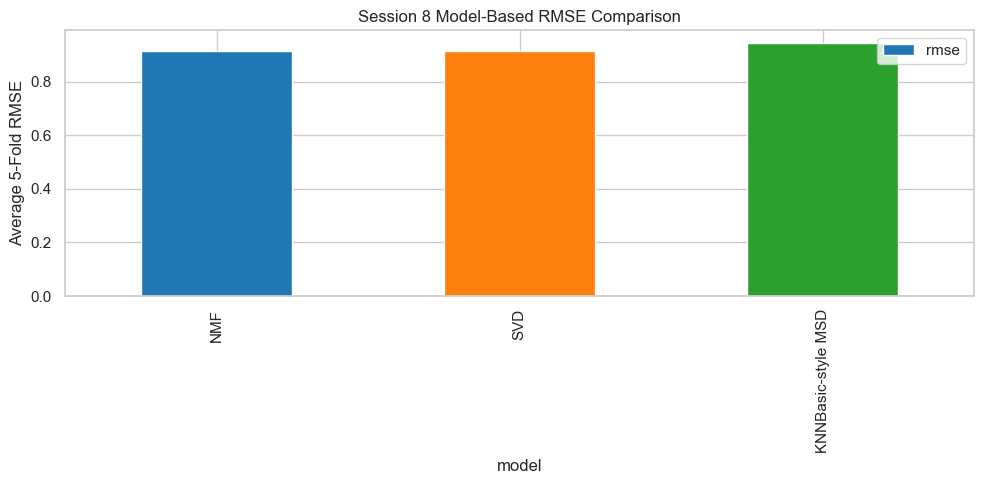

{'movie_id_32_title': 'Twelve Monkeys (a.k.a. 12 Monkeys) (1995)',
 'predicted_user_1_rating_for_movie_32': 4.1369,
 'top_50_user_correlations_saved': 'session_8_top_50_user_correlations.csv',
 'similar_movies_for_jurassic_park': [{'title': 'Fugitive, The (1993)',
   'correlation': 0.3247171394399731},
  {'title': 'Lethal Weapon (1987)', 'correlation': 0.31864593185683193},
  {'title': 'Independence Day (a.k.a. ID4) (1996)',
   'correlation': 0.2636287255242379},
  {'title': 'Mission: Impossible (1996)', 'correlation': 0.2580803862260631},
  {'title': 'Ghostbusters (a.k.a. Ghost Busters) (1984)',
   'correlation': 0.2565274870262607},
  {'title': 'Mulan (1998)', 'correlation': 0.2556717372359885},
  {'title': 'Rise of the Planet of the Apes (2011)',
   'correlation': 0.24813411495015494},
  {'title': "Bug's Life, A (1998)", 'correlation': 0.24096415228304177},
  {'title': 'Indiana Jones and the Temple of Doom (1984)',
   'correlation': 0.23982562683836303},
  {'title': 'Die Hard (1988)

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
summary_results.plot(x='model', y='rmse', kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
ax.set_title('Session 8 Model-Based RMSE Comparison')
ax.set_ylabel('Average 5-Fold RMSE')
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'model_based_rmse.png', dpi=150)
plt.show()
plt.close(fig)

fold_results.to_csv(OUTPUTS_DIR / 'session_8_model_cv_results.csv', index=False)
summary = {
    'movie_id_32_title': movie_32_title,
    'predicted_user_1_rating_for_movie_32': round(predicted_user_1_rating, 4),
    'top_50_user_correlations_saved': 'session_8_top_50_user_correlations.csv',
    'similar_movies_for_jurassic_park': similar_movies_df.to_dict(orient='records'),
    'model_cv_results': summary_results.to_dict(orient='records'),
    'best_model': best_model,
    'environment_note': 'scikit-surprise could not be installed because Microsoft Visual C++ Build Tools are missing in this Windows Python 3.12 environment.',
}
with open(OUTPUTS_DIR / 'session_8_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary